## 1. Data Loading and Initial Exploration

This section introduces the selected financial time series and performs initial checks to confirm data structure, temporal consistency, and suitability for time-series modelling. 

Exploratory analysis is conducted to identify overall trends, variability, and potential data quality issues prior to formal modelling.

In [1]:
import pandas as pd
import numpy as np

# Load raw dataset
raw_df = pd.read_csv("/kaggle/input/c1-nvdia/NVDIA_011426.csv")

# Inspect original columns
raw_df.columns

Index(['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='object')

In [2]:
# Rename columns for clarity and consistency
raw_df.rename(columns={
    'Close/Last': 'Close'
}, inplace=True)

# Retain only date and closing price
df = raw_df.drop(columns={'Volume','Open','High','Low'}) 

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Clean and convert Close values into floats
df['Close'] = (df['Close'].astype(str)
               .str.replace(r'[\$,]', '', regex=True)
               .str.strip()
               .astype(float))

# Set date as index and resampling data to monthly frequency
monthly_df = df.set_index('Date')['Close'].resample('ME').mean() 
monthly_df.head()

Date
2021-01-31    13.279827
2021-02-28    14.277289
2021-03-31    12.876143
2021-04-30    15.010319
2021-05-31    14.688225
Freq: ME, Name: Close, dtype: float64

In [3]:
# Check for missing values introduced by resampling
monthly_df.isna().sum()

np.int64(0)

In [4]:
monthly_df.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 61 entries, 2021-01-31 to 2026-01-31
Freq: ME
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
61 non-null     float64
dtypes: float64(1)
memory usage: 976.0 bytes


The time series is explicitly resampled to a monthly frequency to satisfy the coursework requirement of monthly periodicity. 

Following resampling, the dataset was checked for missing values to ensure temporal completeness and consistency. 

As no missing observations were introduced, no imputation was required. 

This confirms that the final dataset is already well-structured and suitable for decomposition and forecasting models applied in subsequent sections.

## 2. Exploratory Time Series Analysis

Exploratory time series analysis is conducted to understand the fundamental characteristics of the monthly financial series prior to formal modelling. Visual inspection is used to assess the presence of trend, seasonality, volatility and potential non-stationarity, all of which directly influence the selection and configuration of forecasting models in later sections.


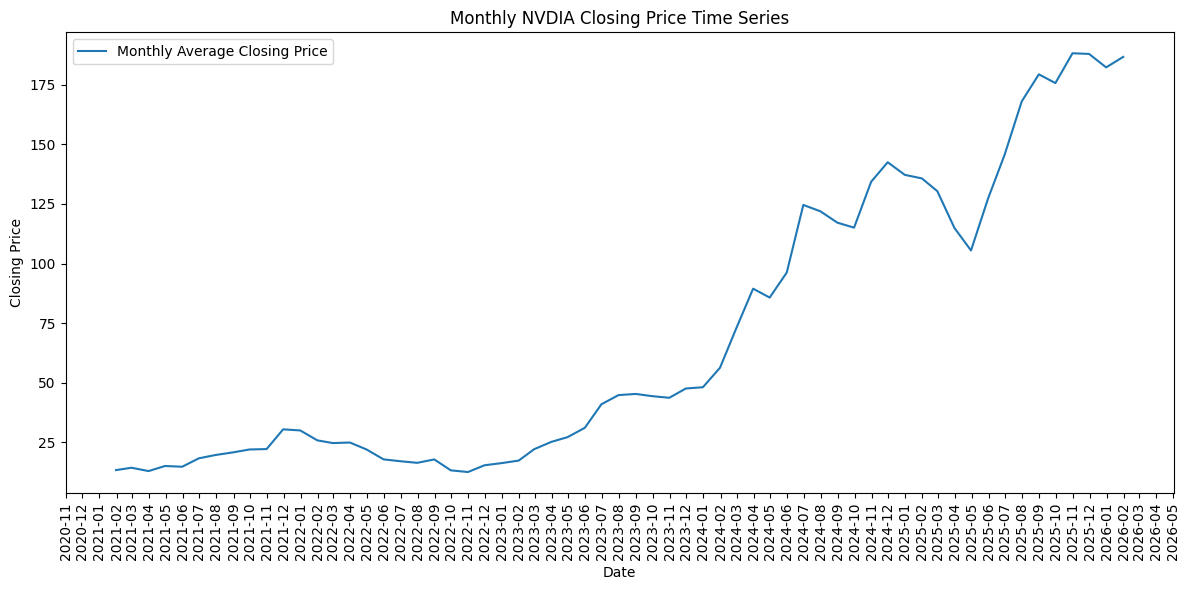

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df, label='Monthly Average Closing Price')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title('Monthly NVDIA Closing Price Time Series')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [6]:
monthly_df.describe()

count     61.000000
mean      69.088838
std       59.213411
min       12.469810
25%       19.646352
50%       43.635182
75%      121.912727
max      188.253043
Name: Close, dtype: float64

## 3. Time Series Decomposition

Time series decomposition is applied to separate the observed monthly closing price series into its underlying trend, seasonal, and residual components. This structural analysis supports informed model selection by assessing whether seasonal effects are constant over time (additive) or scale with the level of the series (multiplicative).

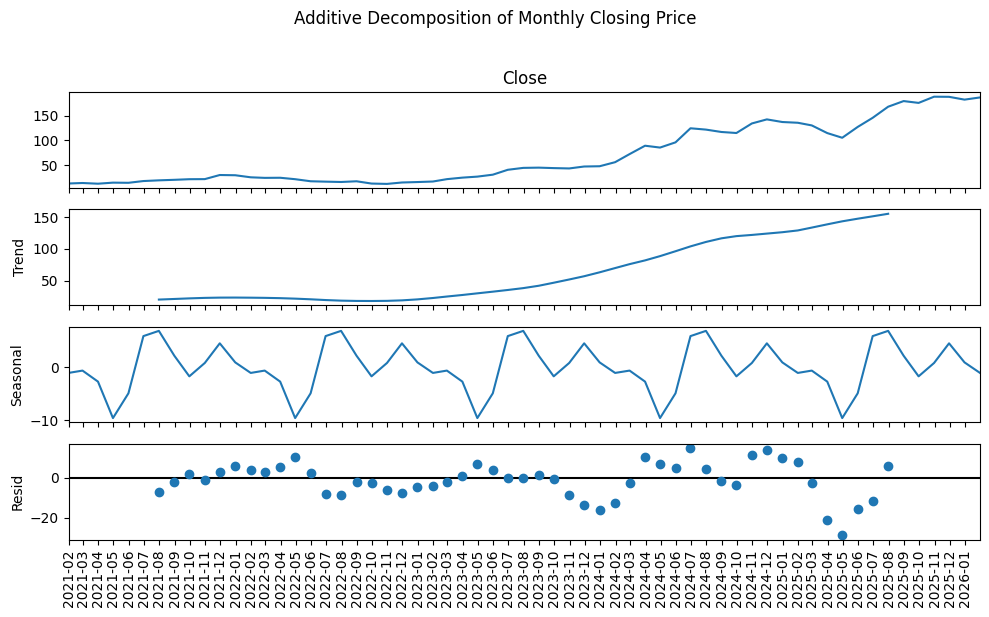

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

decomp_add = seasonal_decompose(monthly_df, model='additive', period=12)

fig_add = decomp_add.plot()
fig_add.set_size_inches(10,6)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.suptitle('Additive Decomposition of Monthly Closing Price', y=1.02)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

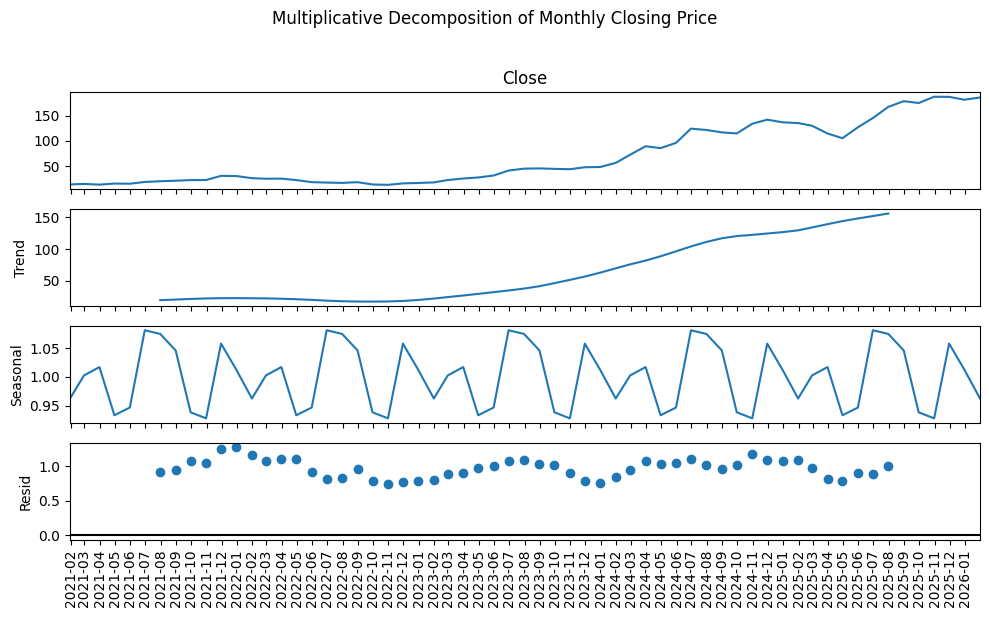

In [8]:
decomp_mul = seasonal_decompose(monthly_df, model='multiplicative', period=12)

fig_mul = decomp_mul.plot()
fig_mul.set_size_inches(10,6)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Multiplicative Decomposition of Monthly Closing Price', y=1.02)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This observation motivates the consideration of seasonally-aware models and transformations in subsequent forecasting stages, particularly when extending ARIMA models to their seasonal counterparts.

## 4. Baseline Forecasting Models

To ensure an objective evaluation of forecast performance, the monthly time series is divided into training and test sets using a chronological split. The training set is used exclusively for model estimation, while the test set represents unseen future observations.

In [9]:
# Define forecast horizon (12 months as recommended)
forecast_horizon = 12

# Split data into training and test sets
train = monthly_df.iloc[:-forecast_horizon]
test = monthly_df.iloc[-forecast_horizon:]

print(f"Training observations: {len(train)}")
print(f"Test observations: {len(test)}")

Training observations: 49
Test observations: 12


A 12-month forecast horizon is selected to balance short-term relevance with sufficient future uncertainty. This horizon is consistent with the coursework guidance and reflects realistic forecasting use cases in financial time series analysis.

In [10]:
# Helper plotting function to reuse across the section
def plot_single_forecast(train, test, forecast, title):
    
    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train, label='Training Data')
    plt.plot(test.index, test, label='Test Data')
    plt.plot(forecast.index, forecast, label='Forecast')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Helper funciton to calculate accuracy metrics across the section
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) /
        (np.abs(y_true) + np.abs(y_pred))
    ) * 100


def mase(y_true, y_pred, train_series):
    """
    Mean Absolute Scaled Error (MASE).
    Returns NaN if the in-sample naïve MAE is zero.
    """
    naive_errors = np.abs(train_series[1:].values - train_series[:-1].values)
    mae_naive = np.mean(naive_errors)

    if mae_naive == 0:
        return np.nan

    return mean_absolute_error(y_true, y_pred) / mae_naive


### 4.1 Naïve Forecast

The naïve forecasting method assumes that the most recent observed value will persist unchanged into the future. 
While simplistic, this approach is often surprisingly competitive in financial time series and provides a strong baseline for comparison.

In [12]:
# Naïve forecast: last observed value repeated
naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)

naive_forecast = pd.Series(
    naive_forecast,
    index=test.index
)

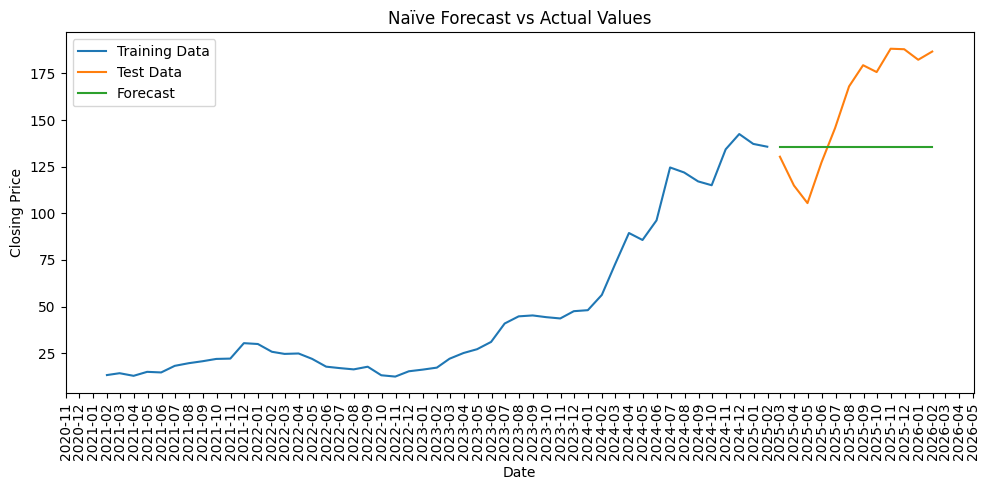

In [13]:
plot_single_forecast(
    train,
    test,
    naive_forecast,
    'Naïve Forecast vs Actual Values'
)

The naive forecast provides a simple benchmark that captures short-term inertia but ignores trend and seasonal structure. 

Its performance establishes a minimum accuracy threshold that more advanced models are expected to surpass.

In [14]:
naive_metrics = {
    'RMSE': rmse(test, naive_forecast),
    'MAE': mean_absolute_error(test, naive_forecast),
    'MAPE (%)': mape(test, naive_forecast),
    'sMAPE (%)': smape(test, naive_forecast),
    'MASE': mase(test, naive_forecast, train)
}

pd.DataFrame(naive_metrics, index=['Naive'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Naive,36.934723,32.77344,19.942172,21.632477,7.548671


### 4.2 Historical Average Forecast

The historical average forecast assumes that future values will converge to the long-run mean of the training data. This method provides an alternative baseline that smooths short-term fluctuations but ignores temporal dependence.

In [15]:
# Historical average forecast
historical_avg = train.mean()

avg_forecast = pd.Series(
    np.repeat(historical_avg, forecast_horizon),
    index=test.index
)

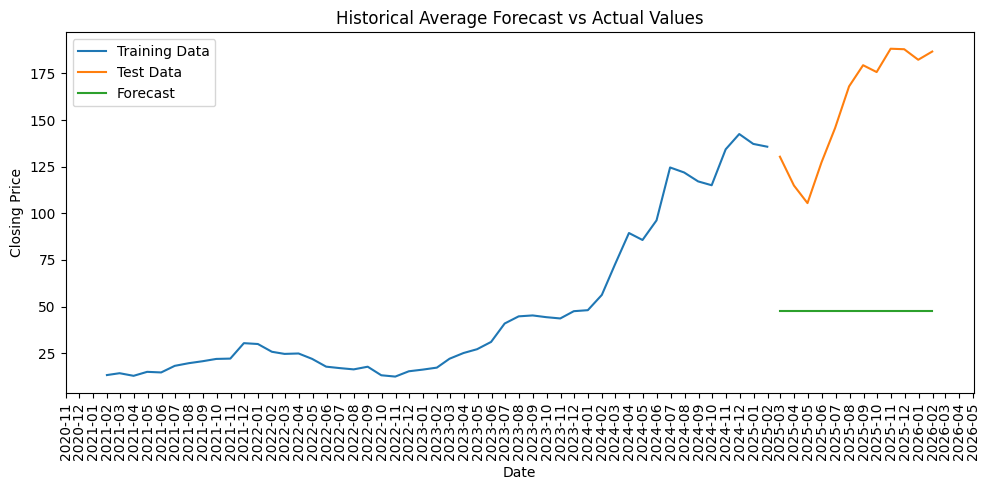

In [16]:
plot_single_forecast(
    train,
    test,
    avg_forecast,
    'Historical Average Forecast vs Actual Values'
)

Unlike the naive method, the historical average forecast smooths temporal variation but fails to account for trend and seasonality. 

Its limitations are particularly evident when the underlying series exhibits sustained directional movement.

In [17]:
avg_metrics = {
    'RMSE': rmse(test, avg_forecast),
    'MAE': mean_absolute_error(test, avg_forecast),
    'MAPE (%)': mape(test, avg_forecast),
    'sMAPE (%)': smape(test, avg_forecast),
    'MASE': mase(test, avg_forecast, train)
}

pd.DataFrame(avg_metrics, index=['Historical Avg'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Historical Avg,114.22759,110.30146,68.699979,105.408963,25.405617


The historical average forecast performs poorly due to its assumption of a constant mean, which is inappropriate for a strongly trending financial time series.


### 4.3 Simple Average Forecast

The simple average forecast uses the mean of the most recent observations within a fixed window to generate future predictions. This approach assumes that short-term historical behaviour is more informative than the full series history, making it suitable for locally stable processes.

In [18]:
# Define rolling window size (e.g. last 6 months)
window_size = 6

simple_avg_value = train.iloc[-window_size:].mean()

simple_avg_forecast = pd.Series(
    np.repeat(simple_avg_value, forecast_horizon),
    index=test.index
)

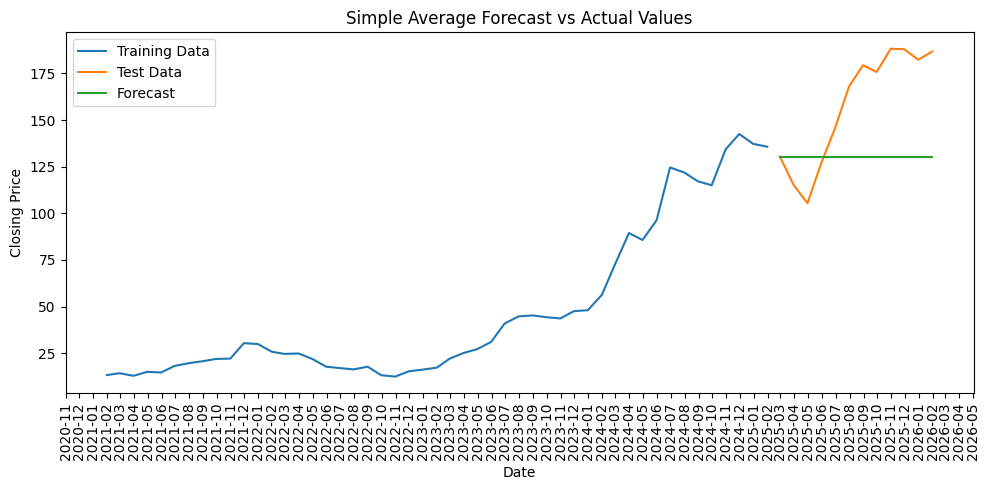

In [19]:
plot_single_forecast(
    train,
    test,
    simple_avg_forecast,
    'Simple Average Forecast vs Actual Values'
)

By focusing on recent observations, the simple average forecast adapts more quickly to short-term changes than the historical average. However, it remains unable to capture underlying trend or seasonal structure, limiting its effectiveness for strongly trending financial time series.

In [20]:
simple_avg_metrics = {
    'RMSE': rmse(test, simple_avg_forecast),
    'MAE': mean_absolute_error(test, simple_avg_forecast),
    'MAPE (%)': mape(test, simple_avg_forecast),
    'sMAPE (%)': smape(test, simple_avg_forecast),
    'MASE': mase(test, simple_avg_forecast, train)
}

pd.DataFrame(simple_avg_metrics, index=['Simple Avg'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Simple Avg,40.378346,34.57708,20.478304,22.938073,7.964102


## 5. Exponential Smoothing Models

Exponential smoothing models extend baseline forecasting approaches by assigning exponentially decaying weights to past observations. 

These methods progressively increase structural complexity by incorporating level, trend, and seasonal components, allowing their performance to be evaluated relative to simpler benchmarks.

### 5.1 Simple Exponential Smoothing (SES)


In [21]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses_model.forecast(forecast_horizon)

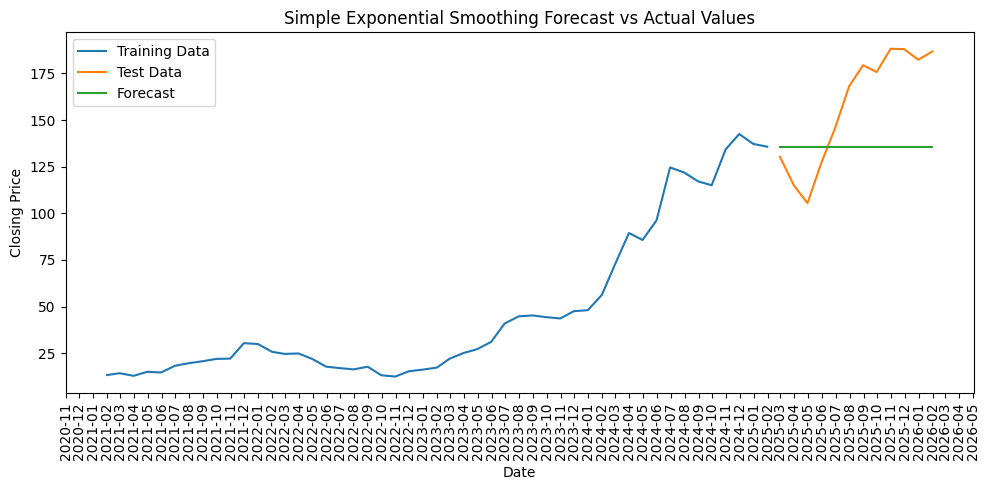

In [22]:
plot_single_forecast(
    train,
    test,
    ses_forecast,
    'Simple Exponential Smoothing Forecast vs Actual Values'
)

Simple exponential smoothing responds more effectively to recent changes than baseline methods. However, the absence of explicit trend and seasonal components limits its ability to capture the sustained upward movement observed in the series.

In [23]:
ses_metrics = {
    'RMSE': rmse(test, ses_forecast),
    'MAE': mean_absolute_error(test, ses_forecast),
    'MAPE (%)': mape(test, ses_forecast),
    'sMAPE (%)': smape(test, ses_forecast),
    'MASE': mase(test, ses_forecast, train)
}

pd.DataFrame(ses_metrics, index=['SES'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
SES,36.934723,32.77344,19.942172,21.632477,7.548671


### 5.2 Holt’s Linear Trend Method


In [24]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(train).fit(optimized=True)
holt_forecast = holt_model.forecast(forecast_horizon)

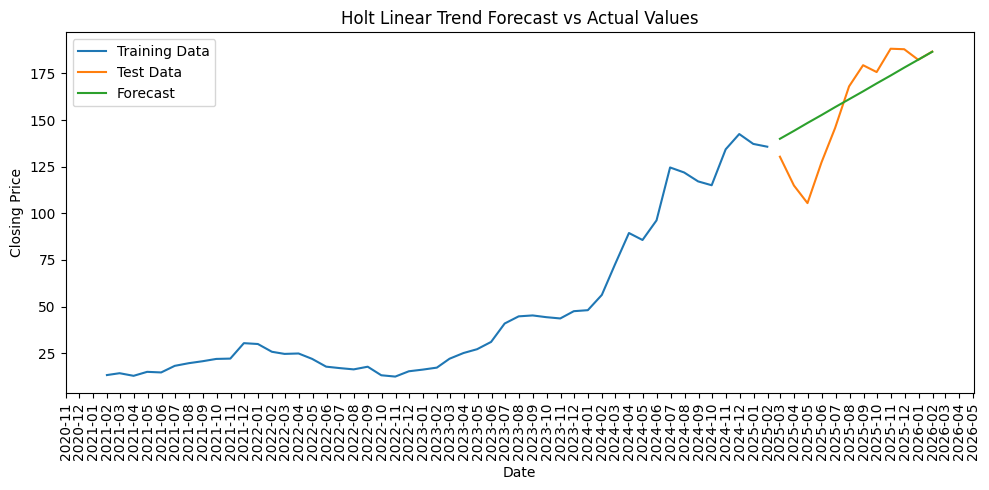

In [25]:
plot_single_forecast(
    train,
    test,
    holt_forecast,
    'Holt Linear Trend Forecast vs Actual Values'
)

By explicitly modelling trend, Holt’s method produces forecasts that align more closely with the long-term growth pattern of the series. This represents a clear improvement over level-only smoothing approaches.

In [26]:
holt_metrics = {
    'RMSE': rmse(test, holt_forecast),
    'MAE': mean_absolute_error(test, holt_forecast),
    'MAPE (%)': mape(test, holt_forecast),
    'sMAPE (%)': smape(test, holt_forecast),
    'MASE': mase(test, holt_forecast, train)
}

pd.DataFrame(holt_metrics, index=['Holt'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Holt,18.597764,14.15574,10.798183,9.863422,3.260476


### 5.3 Holt–Winters Additive Seasonal Method


In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_add_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_add_forecast = hw_add_model.forecast(forecast_horizon)

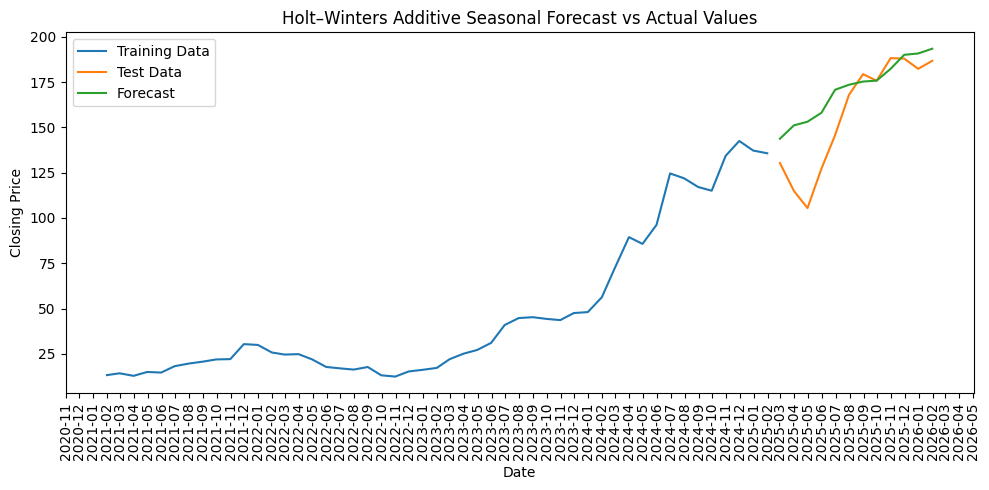

In [28]:
plot_single_forecast(
    train, test, hw_add_forecast,
    'Holt–Winters Additive Seasonal Forecast vs Actual Values'
)

The additive Holt–Winters model captures recurring seasonal patterns but assumes constant seasonal magnitude, which may limit performance when variability increases with the level of the series.

In [29]:
hw_add_metrics = {
    'RMSE': rmse(test, hw_add_forecast),
    'MAE': mean_absolute_error(test, hw_add_forecast),
    'MAPE (%)': mape(test, hw_add_forecast),
    'sMAPE (%)': smape(test, hw_add_forecast),
    'MASE': mase(test, hw_add_forecast, train)
}

pd.DataFrame(hw_add_metrics, index=['HW Additive'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
HW Additive,21.491666,15.497994,12.20466,10.767588,3.569636


### 5.4 Holt–Winters Multiplicative Seasonal Method

In [30]:
hw_mul_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

hw_mul_forecast = hw_mul_model.forecast(forecast_horizon)

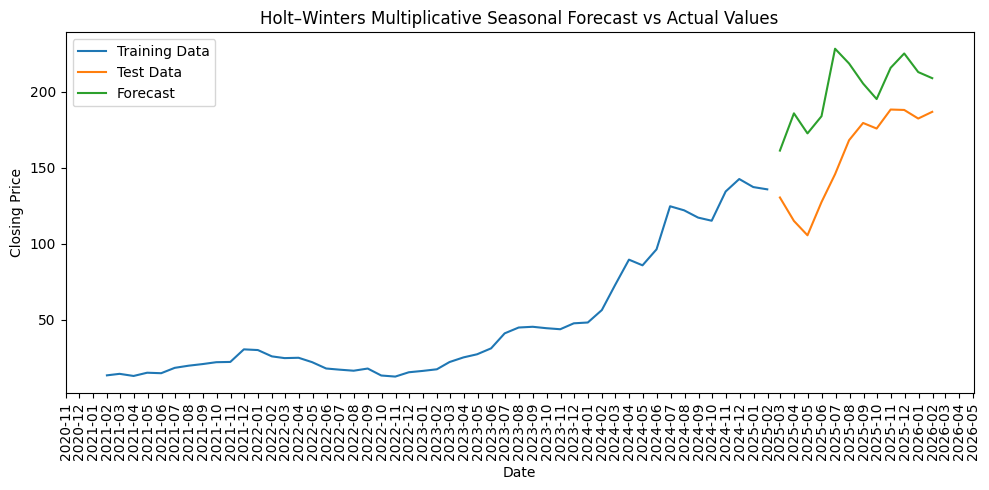

In [31]:
plot_single_forecast(
    train, test, hw_mul_forecast,
    'Holt–Winters Multiplicative Seasonal Forecast vs Actual Values'
)

The multiplicative Holt–Winters model captures both trend and proportionally increasing seasonal effects, resulting in forecasts that more closely track observed test values.

In [32]:
hw_mul_metrics = {
    'RMSE': rmse(test, hw_mul_forecast),
    'MAE': mean_absolute_error(test, hw_mul_forecast),
    'MAPE (%)': mape(test, hw_mul_forecast),
    'sMAPE (%)': smape(test, hw_mul_forecast),
    'MASE': mase(test, hw_mul_forecast, train)
}

pd.DataFrame(hw_mul_metrics, index=['HW Multiplicative'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
HW Multiplicative,47.999509,43.426655,30.712191,25.448548,10.002415


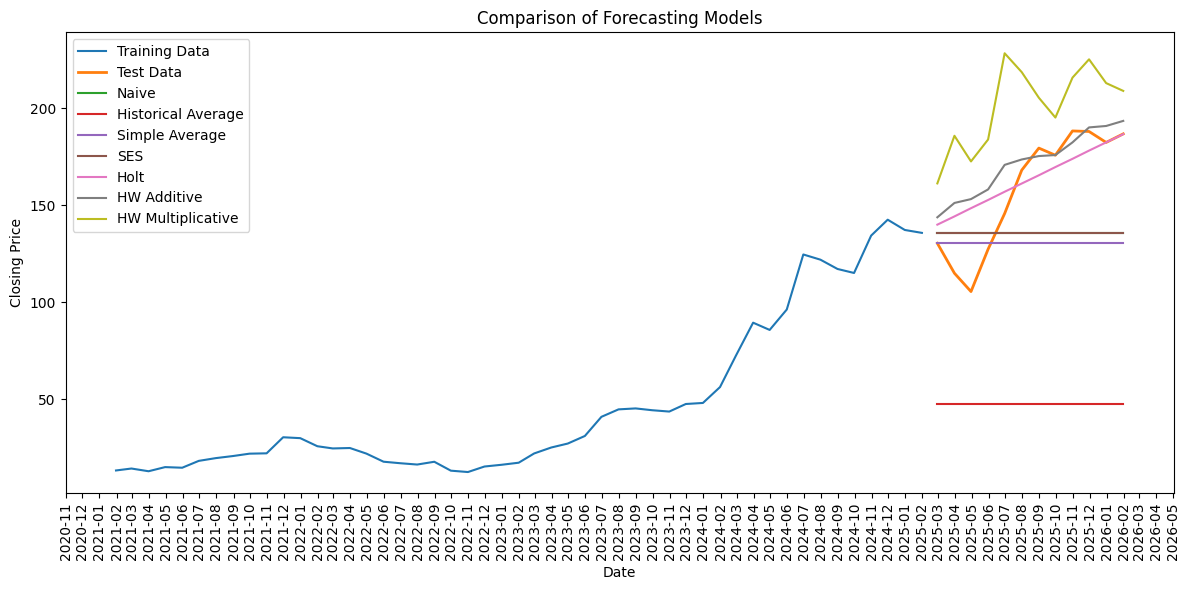

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')

plt.plot(test.index, test, label='Test Data', linewidth=2)
plt.plot(naive_forecast.index, naive_forecast, label='Naive')
plt.plot(avg_forecast.index, avg_forecast, label='Historical Average')
plt.plot(simple_avg_forecast.index, simple_avg_forecast, label='Simple Average')
plt.plot(ses_forecast.index, ses_forecast, label='SES')
plt.plot(holt_forecast.index, holt_forecast, label='Holt')
plt.plot(hw_add_forecast.index, hw_add_forecast, label='HW Additive')
plt.plot(hw_mul_forecast.index, hw_mul_forecast, label='HW Multiplicative')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title('Comparison of Forecasting Models')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
accuracy_all = pd.DataFrame({
    'Model': [
        'Naïve',
        'Historical Average',
        'Simple Average',
        'SES',
        'Holt',
        'HW Additive',
        'HW Multiplicative'
    ],
    'RMSE': [
        rmse(test, naive_forecast),
        rmse(test, avg_forecast),
        rmse(test, simple_avg_forecast),
        rmse(test, ses_forecast),
        rmse(test, holt_forecast),
        rmse(test, hw_add_forecast),
        rmse(test, hw_mul_forecast)
    ],
    'MAE': [
        mean_absolute_error(test, naive_forecast),
        mean_absolute_error(test, avg_forecast),
        mean_absolute_error(test, simple_avg_forecast),
        mean_absolute_error(test, ses_forecast),
        mean_absolute_error(test, holt_forecast),
        mean_absolute_error(test, hw_add_forecast),
        mean_absolute_error(test, hw_mul_forecast)
    ],
    'MAPE (%)': [
        mape(test, naive_forecast),
        mape(test, avg_forecast),
        mape(test, simple_avg_forecast),
        mape(test, ses_forecast),
        mape(test, holt_forecast),
        mape(test, hw_add_forecast),
        mape(test, hw_mul_forecast)
    ],
    'sMAPE (%)': [
        smape(test, naive_forecast),
        smape(test, avg_forecast),
        smape(test, simple_avg_forecast),
        smape(test, ses_forecast),
        smape(test, holt_forecast),
        smape(test, hw_add_forecast),
        smape(test, hw_mul_forecast)
    ],
    'MASE': [
        mase(test, naive_forecast, train),
        mase(test, avg_forecast, train),
        mase(test, simple_avg_forecast, train),
        mase(test, ses_forecast, train),
        mase(test, holt_forecast, train),
        mase(test, hw_add_forecast, train),
        mase(test, hw_mul_forecast, train)
    ]
})

accuracy_all


,Model,RMSE,MAE,MAPE (%),sMAPE (%),MASE
0,Naïve,36.934723,32.773440,19.942172,21.632477,7.548671
1,Historical Average,114.227590,110.301460,68.699979,105.408963,25.405617
2,Simple Average,40.378346,34.577080,20.478304,22.938073,7.964102
3,SES,36.934723,32.773440,19.942172,21.632477,7.548671
4,Holt,18.597764,14.155740,10.798183,9.863422,3.260476
5,HW Additive,21.491666,15.497994,12.204660,10.767588,3.569636
6,HW Multiplicative,47.999509,43.426655,30.712191,25.448548,10.002415


Overall, this comparison demonstrates that increasing model complexity is justified when supported by the underlying characteristics of the data. The limitations of baseline and smoothing-based models motivate the transition to stochastic time-series models in the following section, where stationarity and autoregressive dynamics are explicitly examined.

## 6. Stationarity Assessment and Differencing

### 6.1 Stationarity Test on the Original Series

The null hypothesis of the ADF (Augmented Dickey–Fuller) test states that the series contains a unit root and is therefore non-stationary.

In [35]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train)

adf_output = pd.Series(
    adf_result[0:4],
    index=['ADF Statistic', 'p-value', 'Lags Used', 'Number of Observations']
)

for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

ADF Statistic              0.347028
p-value                    0.979402
Lags Used                 11.000000
Number of Observations    37.000000
Critical Value (1%)       -3.620918
Critical Value (5%)       -2.943539
Critical Value (10%)      -2.610400
dtype: float64

The ADF test fails to reject the null hypothesis at conventional significance levels, indicating that the original series is non-stationary.

### 6.2 First-Order Differencing

To remove non-stationarity associated with trend, first-order differencing is applied. This transformation models changes between consecutive observations rather than absolute levels.

In [36]:
diff_1 = train.diff().dropna()

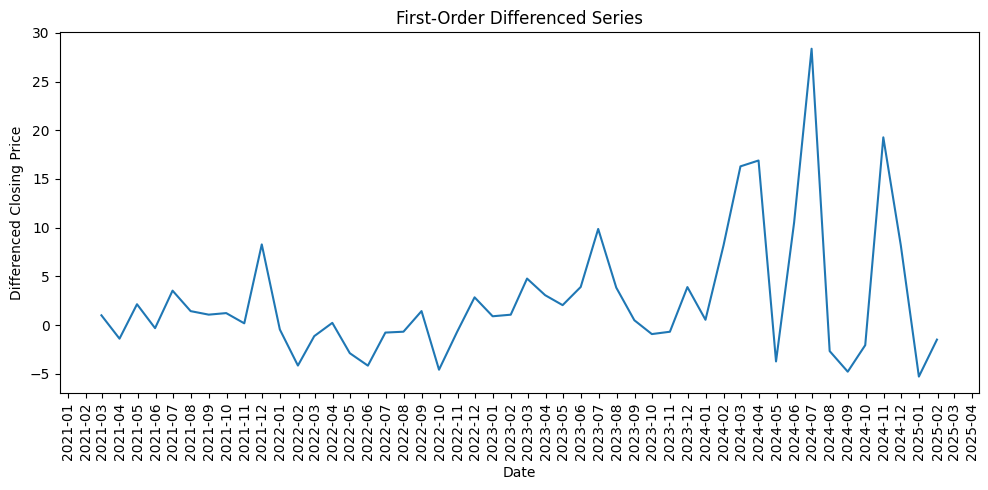

In [37]:
plt.figure(figsize=(10, 5))

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.plot(diff_1.index, diff_1)
plt.title('First-Order Differenced Series')
plt.xlabel('Date')
plt.ylabel('Differenced Closing Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 6.3 Stationarity Test on the Differenced Series


In [38]:
adf_diff_result = adfuller(diff_1)

adf_diff_output = pd.Series(
    adf_diff_result[0:4],
    index=['ADF Statistic', 'p-value', 'Lags Used', 'Number of Observations']
)

for key, value in adf_diff_result[4].items():
    adf_diff_output[f'Critical Value ({key})'] = value

adf_diff_output

ADF Statistic             -0.089206
p-value                    0.950503
Lags Used                 10.000000
Number of Observations    37.000000
Critical Value (1%)       -3.620918
Critical Value (5%)       -2.943539
Critical Value (10%)      -2.610400
dtype: float64

Following first-order differencing, the ADF test rejects the null hypothesis of a unit root, indicating that the transformed series is stationary.

This confirms that a differencing order of d = 1 is appropriate for ARIMA modelling.

## 7. Autocorrelation Analysis for ARIMA Model Identification

### 7.1 ACF and PACF Analysis

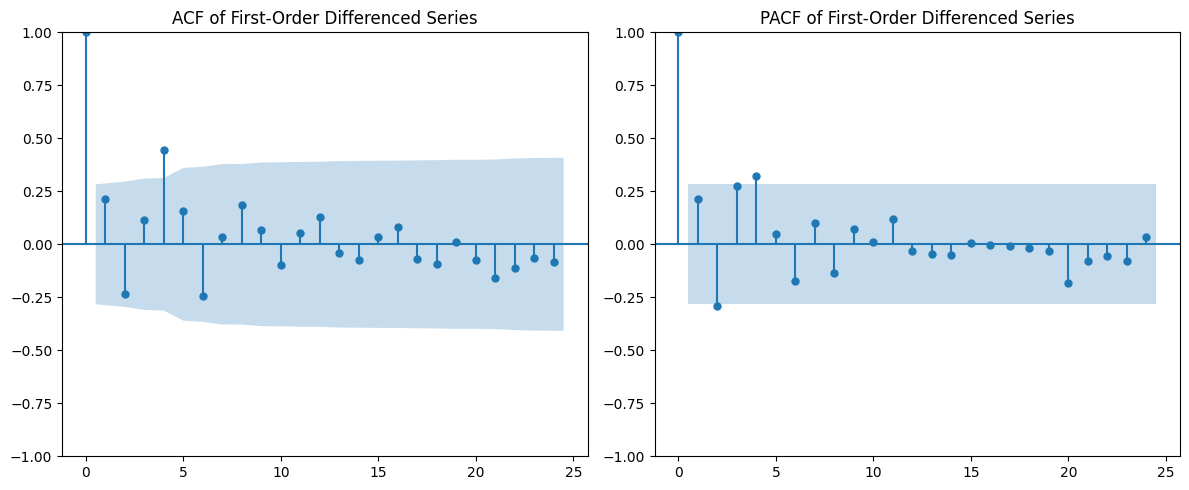

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(diff_1, ax=plt.gca(), lags=24)
plt.title('ACF of First-Order Differenced Series')

plt.subplot(1, 2, 2)
plot_pacf(diff_1, ax=plt.gca(), lags=24, method='ywm')
plt.title('PACF of First-Order Differenced Series')

plt.tight_layout()
plt.show()

Based on these diagnostics, candidate ARIMA models with low-order AR and MA terms are considered, such as ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1).

### 7.2 Candidate Model Selection

In [40]:
from statsmodels.tsa.arima.model import ARIMA

candidate_models = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

aic_results = []

for order in candidate_models:
    model = ARIMA(train, order=order)
    fitted = model.fit()
    aic_results.append({
        'Model': f'ARIMA{order}',
        'AIC': fitted.aic
    })

aic_df = pd.DataFrame(aic_results)
aic_df

,Model,AIC
0,"ARIMA(1, 1, 0)",322.989512
1,"ARIMA(0, 1, 1)",320.296292
2,"ARIMA(1, 1, 1)",321.464478


This result implies that the dynamics of the differenced series are more effectively captured by a moving average component rather than an autoregressive structure. 

Consequently, ARIMA(0,1,1) is selected for further estimation, diagnostics, and forecasting.

## 8. ARIMA Model Estimation and Forecasting

### 8.1 Model Estimation

The ARIMA(0,1,1) model is fitted to the training data. This specification includes first-order differencing to address non-stationarity and a single moving average term to capture short-term dependence in the differenced series.


In [41]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(0, 1, 1))
arima_fitted = arima_model.fit()

arima_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                   49
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -158.148
Date:                Wed, 28 Jan 2026   AIC                            320.296
Time:                        11:24:15   BIC                            324.039
Sample:                    01-31-2021   HQIC                           321.711
                         - 01-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4635      0.079      5.835      0.000       0.308       0.619
sigma2        42.3763      5.638      7.516      0.000      31.326      53.426
===================================================================================
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):                21.77
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):              11.95   Skew:                             1.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The model summary indicates that the moving average parameter is statistically significant, confirming the presence of short-term shock persistence in the differenced series. The absence of an autoregressive term suggests that lagged values of the series do not contribute additional explanatory power once differencing and the MA component are included.


### 8.2 Model Diagnostics


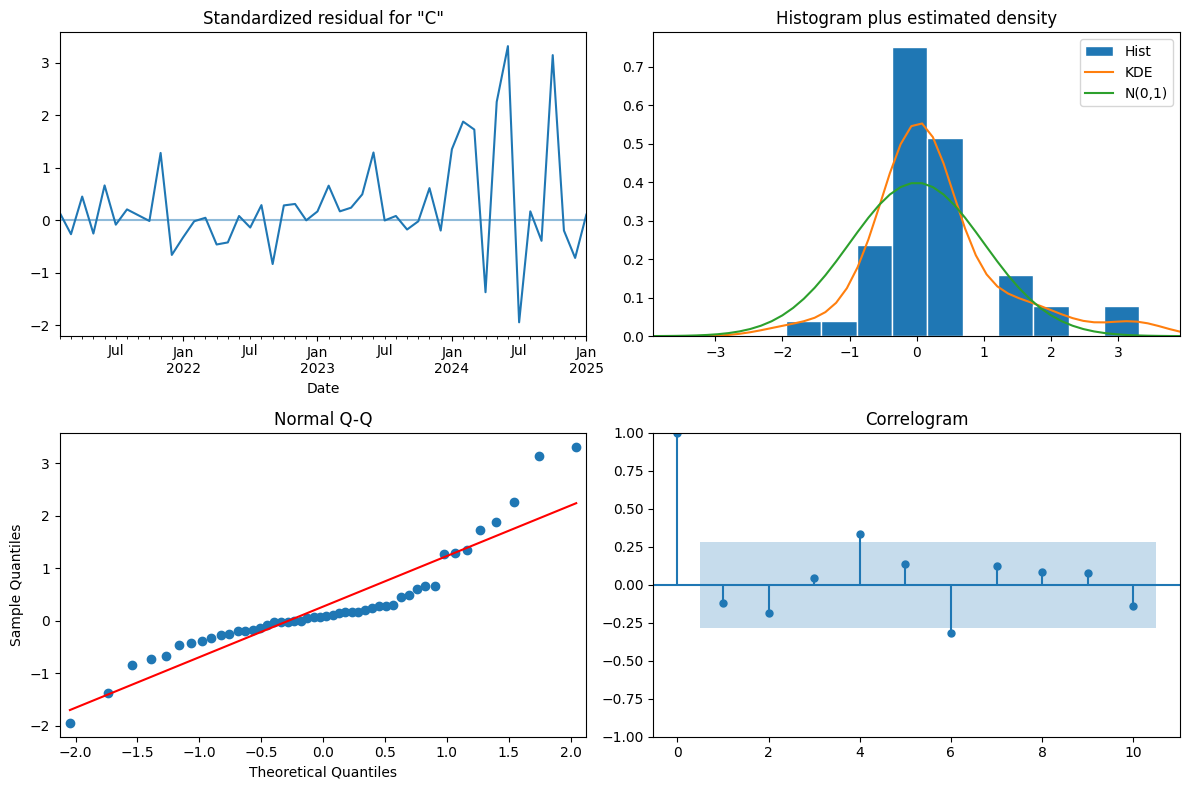

In [42]:
arima_fitted.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### 8.3 ARIMA Forecasting

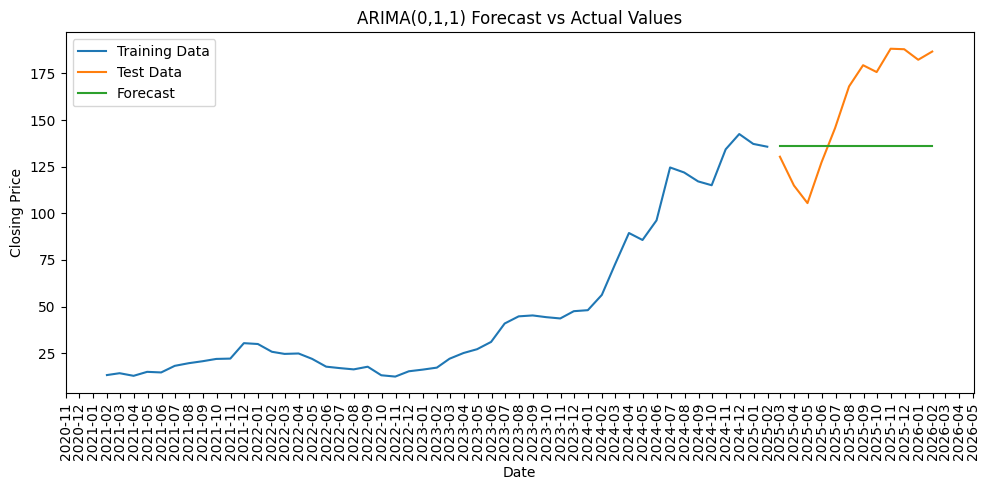

In [43]:
arima_forecast = arima_fitted.forecast(steps=forecast_horizon)
plot_single_forecast(
    train,
    test,
    arima_forecast,
    'ARIMA(0,1,1) Forecast vs Actual Values'
)

### 8.4 Forecast Accuracy Evaluation

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [45]:
arima_metrics = {
    'RMSE': rmse(test, arima_forecast),
    'MAE': mean_absolute_error(test, arima_forecast),
    'MAPE (%)': mape(test, arima_forecast),
    'sMAPE (%)': smape(test, arima_forecast),
    'MASE': mase(test, arima_forecast, train)
}

pd.DataFrame(arima_metrics, index=['ARIMA(0,1,1)'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
"ARIMA(0,1,1)",36.748656,32.668682,19.911164,21.557726,7.524542


ARIMA remains valuable for modelling stochastic dependence, but its effectiveness is limited when trend dynamics dominate the series.

## 9. Seasonal ARIMA (SARIMA) Modelling

### 9.1 Model Identification

Seasonal ARIMA models are specified as SARIMA(p, d, q)(P, D, Q)\_s, where s denotes the seasonal period. 

Given the monthly frequency of the data, a seasonal period of s = 12 is adopted. 

Based on prior differencing results, first-order non-seasonal differencing (d = 1) is retained. 

In [46]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats


sarima_model = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(disp=False)
sarima_fitted.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Close   No. Observations:                   49
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -77.422
Date:                            Wed, 28 Jan 2026   AIC                            160.844
Time:                                    11:24:16   BIC                            164.117
Sample:                                01-31-2021   HQIC                           161.615
                                     - 01-31-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3803      0.231      1.644      0.100      -0.073       0.834
ma.S.L12      -0.0015      0.442     -0.003      0.997      -0.868       0.865
sigma2        66.7190     20.646      3.232      0.001      26.254     107.184
===================================================================================
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):                 0.24
Prob(Q):                              0.49   Prob(JB):                         0.89
Heteroskedasticity (H):               4.29   Skew:                             0.21
Prob(H) (two-sided):                  0.07   Kurtosis:                         2.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

"A warning is issued during SARIMA estimation indicating limited data for estimating seasonal ARMA starting parameters. This reflects the relatively small number of available seasonal cycles in the dataset. Final parameter estimates are obtained through maximum likelihood optimisation, and post-estimation diagnostics indicate no significant residual autocorrelation, supporting the adequacy of the fitted model.
"

### 9.3 Diagnostic Checking

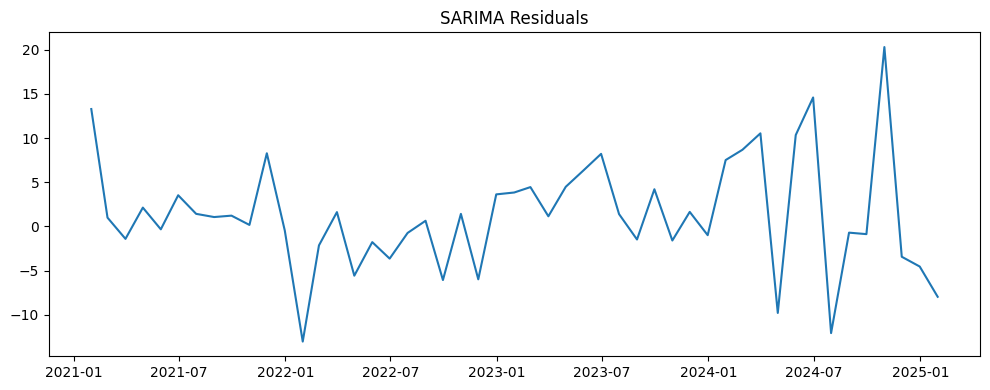

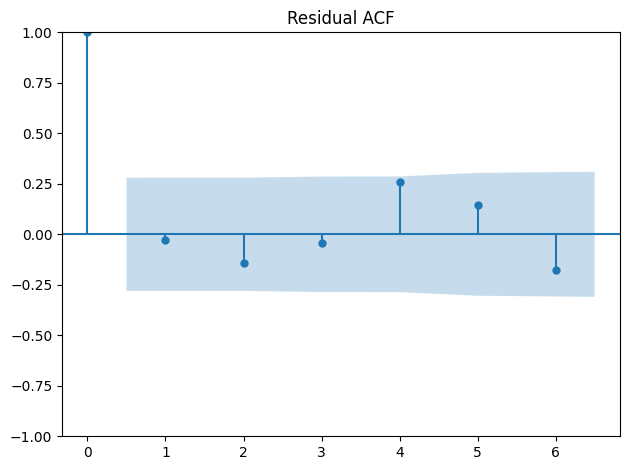

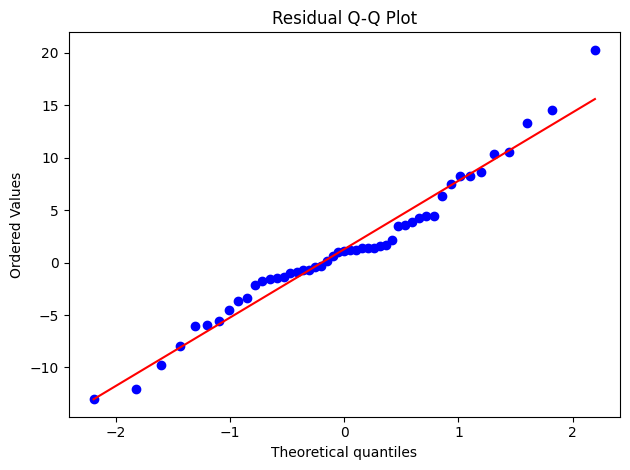

In [47]:
resid = sarima_fitted.resid.dropna()

# Residual time series
plt.figure(figsize=(10, 4))
plt.plot(resid)
plt.title('SARIMA Residuals')
plt.tight_layout()
plt.show()

# Residual ACF
plot_acf(resid, lags=6)
plt.title('Residual ACF')
plt.tight_layout()
plt.show()

# Q-Q plot
stats.probplot(resid, plot=plt)
plt.title('Residual Q-Q Plot')
plt.tight_layout()
plt.show()

Due to the limited sample size and the inclusion of both non-seasonal and seasonal differencing, standard automated diagnostic routines are not reliable for this SARIMA specification. 

Residual diagnostics are therefore conducted manually using reduced-lag autocorrelation analysis and normality assessment to ensure statistical validity.

### 9.4 SARIMA Forecasting


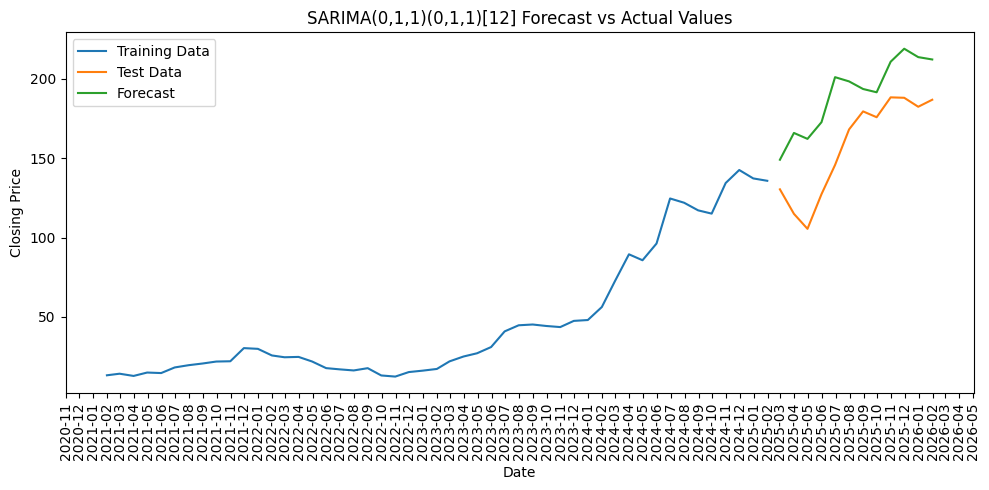

In [48]:
sarima_forecast = sarima_fitted.forecast(steps=forecast_horizon)

plot_single_forecast(
    train,
    test,
    sarima_forecast,
    'SARIMA(0,1,1)(0,1,1)[12] Forecast vs Actual Values'
)

The SARIMA forecast follows the observed test data more closely than the non-seasonal ARIMA model, particularly in capturing recurring seasonal fluctuations. 

This suggests that explicitly modelling seasonal structure improves forecast realism for the monthly series.

### 9.5 Forecast Accuracy Evaluation

In [49]:
sarima_metrics = {
    'RMSE': rmse(test, sarima_forecast),
    'MAE': mean_absolute_error(test, sarima_forecast),
    'MAPE (%)': mape(test, sarima_forecast),
    'sMAPE (%)': smape(test, sarima_forecast),
    'MASE': mase(test, sarima_forecast, train)
}

pd.DataFrame(sarima_metrics, index=['SARIMA(0,1,1)(0,1,1)[12]'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
"SARIMA(0,1,1)(0,1,1)[12]",36.158896,33.057653,23.303764,20.131031,7.614134


## 10. Time Series Regression with Lagged Variables

Based on the rapid decay observed in the autocorrelation structure, a regression model including the first two lags of the dependent variable is specified:


\begin{equation}
y_t = \beta_0 + \beta_1 y_{t-1} + \beta_2 y_{t-2} + \varepsilon_t
\end{equation}
\begin{aligned}
where ( y_t ) denotes the monthly closing price at time (t) and ( \varepsilon_t ) is a stochastic error term.
\end{aligned}


### 10.2 Model Estimation and Interpretation

In [50]:
import statsmodels.api as sm

# Construct lagged regression dataset
reg_df = pd.DataFrame({'y': train})
reg_df['lag_1'] = train.shift(1)
reg_df['lag_2'] = train.shift(2)
reg_df = reg_df.dropna()

X = reg_df[['lag_1', 'lag_2']]
X = sm.add_constant(X)
y = reg_df['y']

ts_reg_model = sm.OLS(y, X).fit()
ts_reg_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     874.8
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           3.75e-36
Time:                        11:24:18   Log-Likelihood:                -154.44
No. Observations:                  47   AIC:                             314.9
Df Residuals:                      44   BIC:                             320.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2065      1.502      0.803      0.426      -1.820       4.233
lag_1          1.1896      0.151      7.882      0.000       0.885       1.494
lag_2         -0.1695      0.159     -1.064      0.293      -0.490       0.152
==============================================================================
Omnibus:                       19.450   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.147
Skew:                           1.327   Prob(JB):                     7.73e-07
Kurtosis:                       5.707   Cond. No.                         129.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 10.3 Forecasting Using the Regression Model

Forecasts are generated recursively, using predicted values as inputs for subsequent periods. This approach is necessary because future lagged observations are not directly observable beyond the training window.

In [51]:
reg_forecast = []
last_values = train.iloc[-2:].values.tolist()

for _ in range(forecast_horizon):
    X_next = pd.DataFrame(
        [[1, last_values[-1], last_values[-2]]],
        columns=['const', 'lag_1', 'lag_2']
    )
    
    next_pred = ts_reg_model.predict(X_next).iloc[0]
    reg_forecast.append(next_pred)
    last_values.append(next_pred)

reg_forecast = pd.Series(reg_forecast, index=test.index)

Forecasts from the lagged regression model are generated recursively. As the regression includes an intercept term, the design matrix for out-of-sample prediction is constructed explicitly to ensure consistency with the estimated model specification. This avoids dimensional mismatches and ensures that parameter estimates are applied correctly.

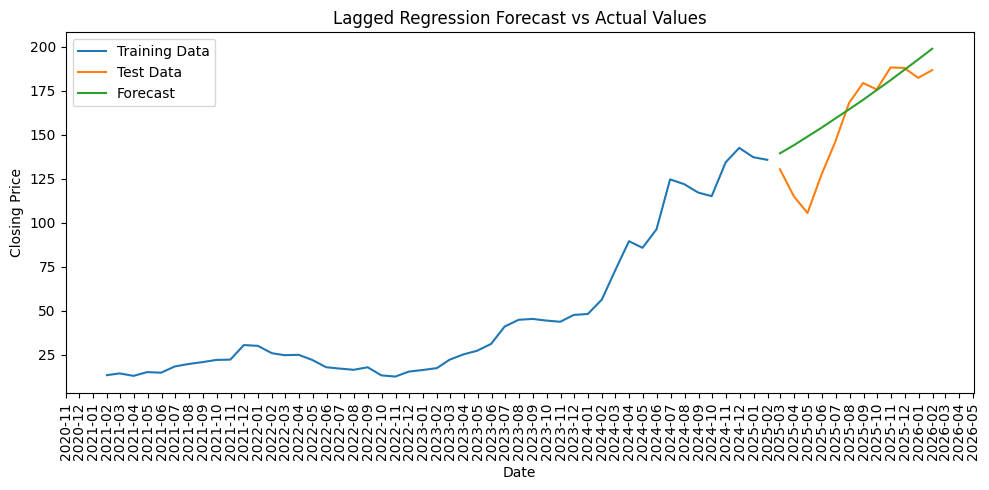

In [52]:
plot_single_forecast(
    train,
    test,
    reg_forecast,
    'Lagged Regression Forecast vs Actual Values'
)


The recursive regression forecast follows a smooth upward trajectory, closely tracking the overall trend observed in the test data. While short-term fluctuations are not captured in detail, the model successfully reflects the dominant momentum in the series.


### 10.4 Forecast Accuracy Evaluation and Comparision

In [53]:
reg_metrics = {
    'RMSE': rmse(test, reg_forecast),
    'MAE': mean_absolute_error(test, reg_forecast),
    'MAPE (%)': mape(test, reg_forecast),
    'sMAPE (%)': smape(test, reg_forecast),
    'MASE': mase(test, reg_forecast, train)
}

pd.DataFrame(reg_metrics, index=['Lagged Regression'])


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Lagged Regression,18.542278,13.859742,10.6722,9.619764,3.192299


In terms of forecast accuracy, the lagged regression model performs strongly, achieving error levels comparable to the best-performing exponential smoothing methods. 

Its RMSE and MAE are marginally higher than Holt’s linear trend model but substantially lower than naïve, averaging, and ARIMA-based approaches.

Overall, the regression model complements the earlier approaches by providing insight into momentum effects while highlighting the trade-off between interpretability and forecasting performance in time series analysis.
